In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt
import platform

# 22 - Digital quantum simulation protocol for Heisenberg model


This tutorial builds a digital protocol that approximates the isotropic Heisenberg interaction using exchange-type couplings and local basis rotations. We compare the analog Heisenberg model (target) with Digital exchange protocol (approximation via Trotterization).

## Heisenberg vs Exchange Interactions

Heisenberg model (isotropic):
  $$H_{Heis} = J\sum_{\langle i,j\rangle} \left(\sigma_x^i\sigma_x^j + \sigma_y^i\sigma_y^j + \sigma_z^i\sigma_z^j\right)$$

Exchange backbone:
  $$H_{XY} = \sum_{\langle i,j\rangle} \left(\sigma_x^i\sigma_x^j + \sigma_y^i\sigma_y^j\right)$$

We digitally synthesize the full Heisenberg term by combining XY couplings with basis rotations:
- Conjugation with rotations maps XY → Z components
- Sequence XY + rotated-XY along x and y axes reproduces x, y, z parts



In [2]:
# parameters for the Hamiltonian
numOfQubits = 2
freequency = 0 
freeOperator = qg.Jz 
couplingStrength = 1

We create two systems:
- nQubExchange: exchange-only system for the digital protocol
- nQubHeisenberg: analog target with full Heisenberg coupling


In [3]:
nQubExchange = numOfQubits * qg.Qubit(frequency=freequency, operator=freeOperator)
nQubHeisenberg = numOfQubits * qg.Qubit(frequency=freequency, operator=freeOperator)

Exchange system: add $\sigma_{x}\sigma_{x}$ and $\sigma_{y}\sigma_{y}$ for neighboring pairs with frequency=0 (will be activated during protocol steps).


In [4]:
exchangeQubs = list(nQubExchange.subSys.values())
for ind in range(numOfQubits-1):
    es = [exchangeQubs[ind], exchangeQubs[ind+1]]
    nQubExchange.createTerm(operator=[qg.sigmax, qg.sigmax], frequency=0, qSystem=es)
    nQubExchange.createTerm(operator=[qg.sigmay, qg.sigmay], frequency=0, qSystem=es)

Heisenberg system: add $\sigma_{x}\sigma_{x}$, $\sigma_{y}\sigma_{y}$, $\sigma_{z}\sigma_{z}$ for neighboring pairs with frequency=1.

This yields a clean separation between the digital building blocks (XY) and the target (XYZ).


In [5]:
HeisenbergQubs = list(nQubHeisenberg.subSys.values())
for ind in range(numOfQubits-1):
    hs = [HeisenbergQubs[ind], HeisenbergQubs[ind+1]]
    nQubHeisenberg.createTerm(operator=[qg.sigmax, qg.sigmax], frequency=couplingStrength, qSystem=hs)
    nQubHeisenberg.createTerm(operator=[qg.sigmay, qg.sigmay], frequency=couplingStrength, qSystem=hs)
    nQubHeisenberg.createTerm(operator=[qg.sigmaz, qg.sigmaz], frequency=couplingStrength, qSystem=hs)

We construct a `qProtocol` composed of:
1. `s1`: free evolution step (here the on-site terms are 0 → identity; keeps timing structure)
2. `s2`: an exchange step that activates pairs of XY couplings at frequency J/2
3. `xRots`: global ±π/2 rotations around x
4. `yRots`: global ±π/2 rotations around y

The protocol sequence (one Trotter step):
- [s1, s2, xRots(+), s2, xRots(-), yRots(+), s2, yRots(-)]
  - s2 implements XY
  - Conjugation by x-rotations maps XY components to include Z contributions
  - Conjugation by y-rotations similarly completes the isotropic combination
  
This approximates the Heisenberg model.

In [6]:
s1 = qg.freeEvolution(superSys=nQubExchange)

s2 = qg.qProtocol(superSys=nQubExchange)
exchangeCouplings = list(nQubExchange.terms.values())
ind = 0
while ind in range(len(exchangeCouplings)):
    u1 = qg.freeEvolution(superSys=nQubExchange)
    u1.createUpdate(system=[exchangeCouplings[ind], exchangeCouplings[ind+1]], key='frequency', value=couplingStrength/2)
    u1.createUpdate(system=exchangeQubs, key='frequency', value=0)
    s2.addStep(u1)
    ind += 2

xRots = [qg.xGate(system=exchangeQubs, angle=np.pi/2, rotationAxis='x'), 
         qg.xGate(system=exchangeQubs, angle=-np.pi/2, rotationAxis='x')]
yRots = [qg.xGate(system=exchangeQubs, angle=np.pi/2, rotationAxis='y'), 
         qg.xGate(system=exchangeQubs, angle=-np.pi/2, rotationAxis='y')]

protocol = qg.qProtocol(superSys=nQubExchange, steps=[s1,s2,xRots[0],s2,xRots[1],yRots[0],s2,yRots[1]])

We run a Simulation with two subsystems in parallel:
- Digital: nQubExchange with the protocol
- Analog: nQubHeisenberg

We compute the following metrics:
- State fidelity between digital and analog: $\mathcal{F}(\psi_{dig}, \psi_{Heis}) = |\langle \psi_{dig}|\psi_{Heis}\rangle|^2$
- Unitary distance (preCompute): spectral norm of difference between protocol unitary powers
- State error (preCompute/postCompute): norms and fidelities from initial/final states
- Expectation values: composite $\sigma_z$ on each subsystem


In [7]:
stepSizes = [0.01*(i+1) for i in range(50)]
freqValues = [0.01*(i+1) for i in range(100)]
totalSimTimeV = 5*2*np.pi

def preCompute(qsim):
    proList = qsim.qEvolutions
    pro1 = (proList[0].unitary()**qsim.stepCount)
    pro2 = (proList[1].unitary()**qsim.stepCount)
    uDiff = pro1 - pro2
    qsim.qRes.singleResult = 'uDiff', qg.spectralNorm(uDiff)
    qsim.qRes.singleResult = 'sErr', qg.norm(uDiff @ proList[0].initialState)
    qsim.qRes.singleResult = 'sFidStart', qg.fidelityPure(pro1@proList[0].initialState, pro2@proList[1].initialState)

def postCompute(qsim):
    proList = qsim.qEvolutions
    qsim.qRes.singleResult = 'sFidEnd', qg.fidelityPure(proList[0].currentState, proList[1].currentState)

sigmaZ = qg.compositeOp(qg.sigmaz(), 2**(numOfQubits-1))
def compute(qsim, args):
    res = qsim.qRes
    res.singleResult = 'state fidelity', qg.fidelityPure(args[0], args[1])
    for key, _ in qsim.subSys.items():
        res.singleResult = [key.name.name+'Exp', qg.expectation(sigmaZ, key.currentState)]

simulation = qg.Simulation()
simulation.initialStateSystem = nQubHeisenberg
simulation.initialState = [0 if x < 1 else 1 for x in range(numOfQubits)]
simulation.delStates = True

simulation.addSubSys(nQubExchange, protocol)
simulation.addSubSys(nQubHeisenberg)

simulation.compute = compute
simulation.postCompute = postCompute
simulation.preCompute = preCompute
simulation.totalTime = totalSimTimeV
simulation.stepSize = (stepSizes[0]+0.05)*2*np.pi

# stepSizeSweep = simulation.Sweep.createSweep(system=simulation, sweepKey='stepSize', sweepList=stepSizes)
freqSweep = simulation.Sweep.createSweep(system=[*exchangeQubs, *HeisenbergQubs], sweepKey='frequency', sweepList=freqValues)

<span style="color:red" font-weight="bold"> IMPORTANT NOTE FOR WINDOWS USERS : MULTI-PROCESSING (p=True) DOES NOT WORK WITH NOTEBOOK

You can use a python script, but you will need to make sure that the critical parts of the code are under ``` if __name__ == "__main__": ``` We are going to add further tutorials for this later.

In [8]:
simulation.run(p=(platform.system() != 'Windows'))

Starting sequential sweep with 100 parameter combinations...
Simulation Start:	2025-11-30 20:59:01
[████████████████████████████████████████] 100.0% | Est. Finish: 2025-11-30 20:59:09
Simulation completed in 00h 00m 07s

[]

In [9]:
res = simulation.resultsDict


We report the fidelity between the digital protocol and the analog Heisenberg model:
- Start fidelity: $\mathcal{F}_{start} = |\langle \psi_{dig}^{(0)} | \psi_{Heis}^{(0)} \rangle|^2$
- End fidelity: $\mathcal{F}_{end} = |\langle \psi_{dig}^{(T)} | \psi_{Heis}^{(T)} \rangle|^2$

These represent how close the protocol’s unitary is to the target at the beginning and after the full evolution.

High fidelity across cavity frequency values indicate good digital approximation of Heisenberg from our Trotterisation protocol.


Start fidelity: 0.9999999999999134  | End fidelity: 0.9999999999999103


Text(0, 0.5, 'Time')

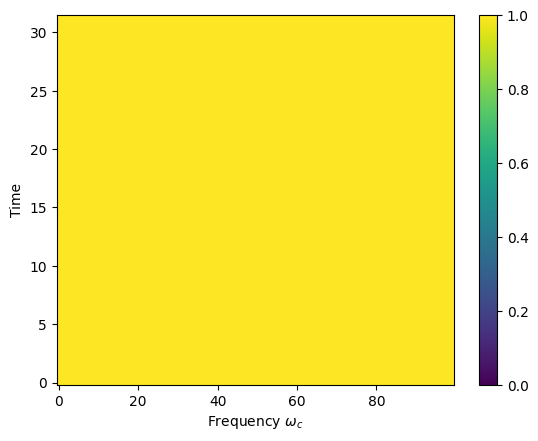

In [17]:
print("Start fidelity:", res['sFidStart'][ind], " | End fidelity:", res['sFidEnd'][ind])

Y, X = np.meshgrid(simulation.timeList, [i for i in range(len(freqSweep.sweepList))])

plt.pcolormesh(X, Y, res['state fidelity'], vmin=0, vmax=1)
plt.colorbar()

plt.xlabel("Frequency $\omega_{c}$")
plt.ylabel("Time")